<a href="https://colab.research.google.com/github/oswram19/parcial4_oswaldoramirez_1764382012/blob/main/agrupacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/oswram19/parcial4_oswaldoramirez_1764382012/refs/heads/main/data/clave_D_agrupacion.csv")
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,D-R0063,35,444,1.58,5.00,8.00,1,17
1,D-R0103,49,712,8.23,74.67,8.89,2,22
2,D-R0141,49,1632,9.47,150.66,7.90,0,36
3,D-R0077,39,968,8.16,91.96,9.59,12,12
4,D-R0119,34,675,5.66,59.92,9.03,0,16


### Selección de Variables para Clustering


VERIFICAR DATOS NULOS

In [5]:
print("\nMissing values per column:")
print(df.info())


Missing values per column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       242 non-null    object 
 1   edad              242 non-null    int64  
 2   ingresos          242 non-null    int64  
 3   frecuencia_uso    242 non-null    float64
 4   gasto_promedio    242 non-null    float64
 5   satisfaccion      241 non-null    float64
 6   reclamos          242 non-null    int64  
 7   antiguedad_meses  242 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 15.3+ KB
None


In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Definir las características seleccionadas para el clustering
clustering_features = [
    'edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio',
    'satisfaccion', 'reclamos', 'antiguedad_meses'
]

# Crear un DataFrame con solo las características seleccionadas
X = df[clustering_features].copy() # Usar .copy() para evitar SettingWithCopyWarning

# Manejar valores faltantes en 'satisfaccion' antes de escalar
# La columna 'satisfaccion' tiene un valor nulo, lo imputaremos con la media
if X['satisfaccion'].isnull().any():
    mean_satisfaccion = X['satisfaccion'].mean()
    X['satisfaccion'].fillna(mean_satisfaccion, inplace=True)
    print(f"Valor nulo en 'satisfaccion' imputado con la media: {mean_satisfaccion:.2f}")

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el escalador a los datos y transformar los datos
X_scaled = scaler.fit_transform(X)

# Convertir los datos escalados de nuevo a un DataFrame para una inspección más fácil
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print("\nDatos Escalados (primeras 5 filas):")
display(X_scaled_df.head())

Valor nulo en 'satisfaccion' imputado con la media: 6.97

Datos Escalados (primeras 5 filas):


/tmp/ipykernel_10688/2160698254.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['satisfaccion'].fillna(mean_satisfaccion, inplace=True)


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,-0.180701,-1.300348,-1.237606,-1.558043,0.573058,-0.690986,-0.092941
1,1.246373,-0.670307,0.963509,-0.081174,1.068423,-0.191826,0.290876
2,1.246373,1.492519,1.373943,1.529667,0.517398,-1.190146,1.365565
3,0.227034,-0.068477,0.940340,0.285341,1.458037,4.799775,-0.476758
4,-0.282635,-0.757290,0.112853,-0.393845,1.146346,-1.190146,-0.169704


# Justificar por qué seleccionó esas variables.

### Justificación de la Selección de Variables para Clustering

Las variables seleccionadas (`edad`, `ingresos`, `frecuencia_uso`, `gasto_promedio`, `satisfaccion`, `reclamos`, `antiguedad_meses`) se eligieron por las siguientes razones:

1.  **Cuantificables y Numéricas:** Los algoritmos de clustering, como K-Means (un método común), operan mejor con datos numéricos para calcular distancias y similitudes entre los puntos de datos. Todas las variables seleccionadas son numéricas y representan características mensurables de los clientes.

2.  **Relevancia para la Segmentación de Clientes:**
    *   **`edad`**: Permite identificar segmentos de clientes por grupos de edad, que a menudo se correlacionan con diferentes necesidades y comportamientos.
    *   **`ingresos`**: Es un indicador clave del poder adquisitivo y el estatus socioeconómico, fundamental para segmentar por capacidad de gasto.
    *   **`frecuencia_uso`**: Mide la actividad del cliente con el servicio o producto, diferenciando usuarios ocasionales de frecuentes.
    *   **`gasto_promedio`**: Refleja el valor transaccional de un cliente, ayudando a identificar clientes de alto y bajo valor.
    *   **`satisfaccion`**: Es crucial para entender la percepción del cliente y segmentar por niveles de lealtad o riesgo de abandono.
    *   **`reclamos`**: Indica problemas o insatisfacciones pasadas, útil para identificar clientes con experiencias negativas que requieren atención especial.
    *   **`antiguedad_meses`**: Mide la lealtad y el ciclo de vida del cliente, permitiendo segmentar por clientes nuevos, consolidados o de larga duración.

3.  **Exclusión de `registro_id`:** La variable `registro_id` fue excluida porque es un identificador único para cada cliente. No proporciona ninguna información descriptiva o característica que pueda ayudar a agrupar a los clientes en segmentos. Incluirla solo añadiría ruido al proceso de clustering, ya que cada `registro_id` es único y no contribuye a la formación de grupos basados en similitudes de características.

VERIFICAR LA MEDIA DE LOS DATOS ESCALADOS

In [10]:
# Verificar la media de los datos escalados
print("Media de los datos escalados por columna:")
display(X_scaled_df.mean())

# Verificar la desviación estándar de los datos escalados
print("\nDesviación estándar de los datos escalados por columna:")
display(X_scaled_df.std())

Media de los datos escalados por columna:


,0
edad,-9.542413e-17
ingresos,1.394660e-16
frecuencia_uso,-8.074349e-17
gasto_promedio,-1.468064e-17
satisfaccion,1.064346e-16
reclamos,7.340318e-18
antiguedad_meses,2.569111e-17



Desviación estándar de los datos escalados por columna:


,0
edad,1.002073
ingresos,1.002073
frecuencia_uso,1.002073
gasto_promedio,1.002073
satisfaccion,1.002073
reclamos,1.002073
antiguedad_meses,1.002073


# Aplicar el método del codo o una técnica para seleccionar el número de grupos.

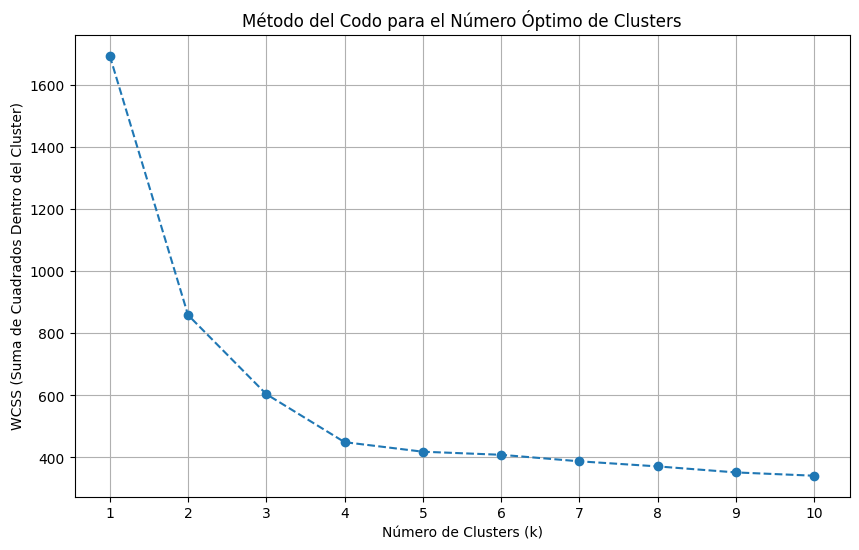

In [11]:
from sklearn.cluster import KMeans

wcss = []
k_values = range(1, 11) # Probar con k desde 1 hasta 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('Método del Codo para el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Suma de Cuadrados Dentro del Cluster)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Aplicar K-Means u otro algoritmo de agrupación.

In [12]:
# Reemplaza 'optimal_k' con el número de clusters que determinaste del gráfico del codo.
# Por ejemplo, si el codo está en 3, usa n_clusters=3.
optimal_k = 3 # Puedes ajustar este valor manualmente después de revisar el gráfico

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_df)

# Añadir las etiquetas de los clusters al DataFrame escalado y al original
X_scaled_df['cluster'] = clusters
df['cluster'] = clusters

print(f"Se han creado {optimal_k} clusters.")
print("Primeras 5 filas con las etiquetas de cluster añadidas al DataFrame escalado:")
display(X_scaled_df.head())
print("\nPrimeras 5 filas con las etiquetas de cluster añadidas al DataFrame original:")
display(df.head())

Se han creado 3 clusters.
Primeras 5 filas con las etiquetas de cluster añadidas al DataFrame escalado:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,-0.180701,-1.300348,-1.237606,-1.558043,0.573058,-0.690986,-0.092941,0
1,1.246373,-0.670307,0.963509,-0.081174,1.068423,-0.191826,0.290876,1
2,1.246373,1.492519,1.373943,1.529667,0.517398,-1.190146,1.365565,2
3,0.227034,-0.068477,0.940340,0.285341,1.458037,4.799775,-0.476758,0
4,-0.282635,-0.757290,0.112853,-0.393845,1.146346,-1.190146,-0.169704,1



Primeras 5 filas con las etiquetas de cluster añadidas al DataFrame original:


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,D-R0063,35,444,1.58,5.00,8.00,1,17,0
1,D-R0103,49,712,8.23,74.67,8.89,2,22,1
2,D-R0141,49,1632,9.47,150.66,7.90,0,36,2
3,D-R0077,39,968,8.16,91.96,9.59,12,12,0
4,D-R0119,34,675,5.66,59.92,9.03,0,16,1


### Análisis de los Clusters

Para entender las características de cada cluster, podemos observar la distribución de observaciones en cada uno y calcular las medias de las variables originales para cada grupo.

In [14]:
# Conteo de observaciones por cluster
print("Conteo de observaciones por cluster:")
display(df['cluster'].value_counts().sort_index())

# Características promedio de cada cluster (usando el DataFrame original no escalado)
print("\nCaracterísticas promedio de cada cluster (usando el DataFrame original):")
display(df.groupby('cluster')[clustering_features].mean())

Conteo de observaciones por cluster:


,count
cluster,
0,117
1,67
2,58



Características promedio de cada cluster (usando el DataFrame original):


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,32.726496,703.495726,2.840256,42.707863,5.484103,3.863248,8.623932
1,33.910448,1012.716418,6.642985,82.050000,7.968939,1.149254,18.970149
2,48.241379,1571.448276,8.790000,146.597586,8.832414,0.827586,36.672414


In [15]:
display(df.head())

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,D-R0063,35,444,1.58,5.00,8.00,1,17,0
1,D-R0103,49,712,8.23,74.67,8.89,2,22,1
2,D-R0141,49,1632,9.47,150.66,7.90,0,36,2
3,D-R0077,39,968,8.16,91.96,9.59,12,12,0
4,D-R0119,34,675,5.66,59.92,9.03,0,16,1


visualizacion de los clusters

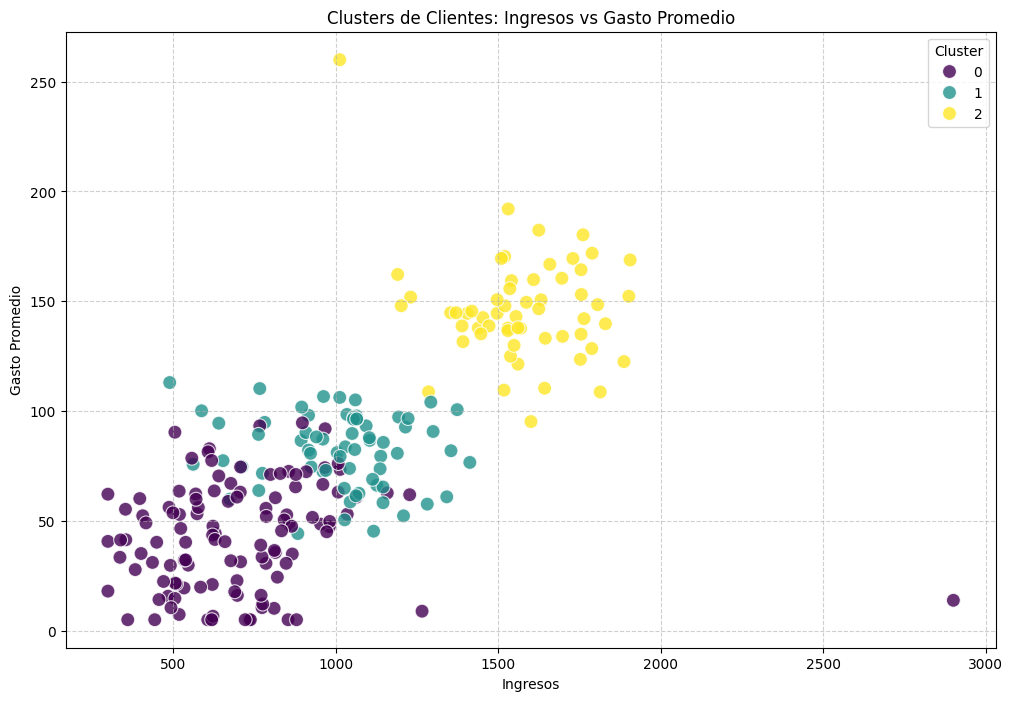

In [16]:
# Gráfico de dispersión de 'ingresos' vs 'gasto_promedio' coloreado por cluster
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='ingresos', y='gasto_promedio', hue='cluster', palette='viridis', s=100, alpha=0.8)
plt.title('Clusters de Clientes: Ingresos vs Gasto Promedio')
plt.xlabel('Ingresos')
plt.ylabel('Gasto Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

/tmp/ipykernel_10688/204556302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='cluster', y=feature, data=df, palette='viridis')
/tmp/ipykernel_10688/204556302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='cluster', y=feature, data=df, palette='viridis')
/tmp/ipykernel_10688/204556302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='cluster', y=feature, data=df, palette='viridis')
/tmp/ipykernel_10688/204556302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

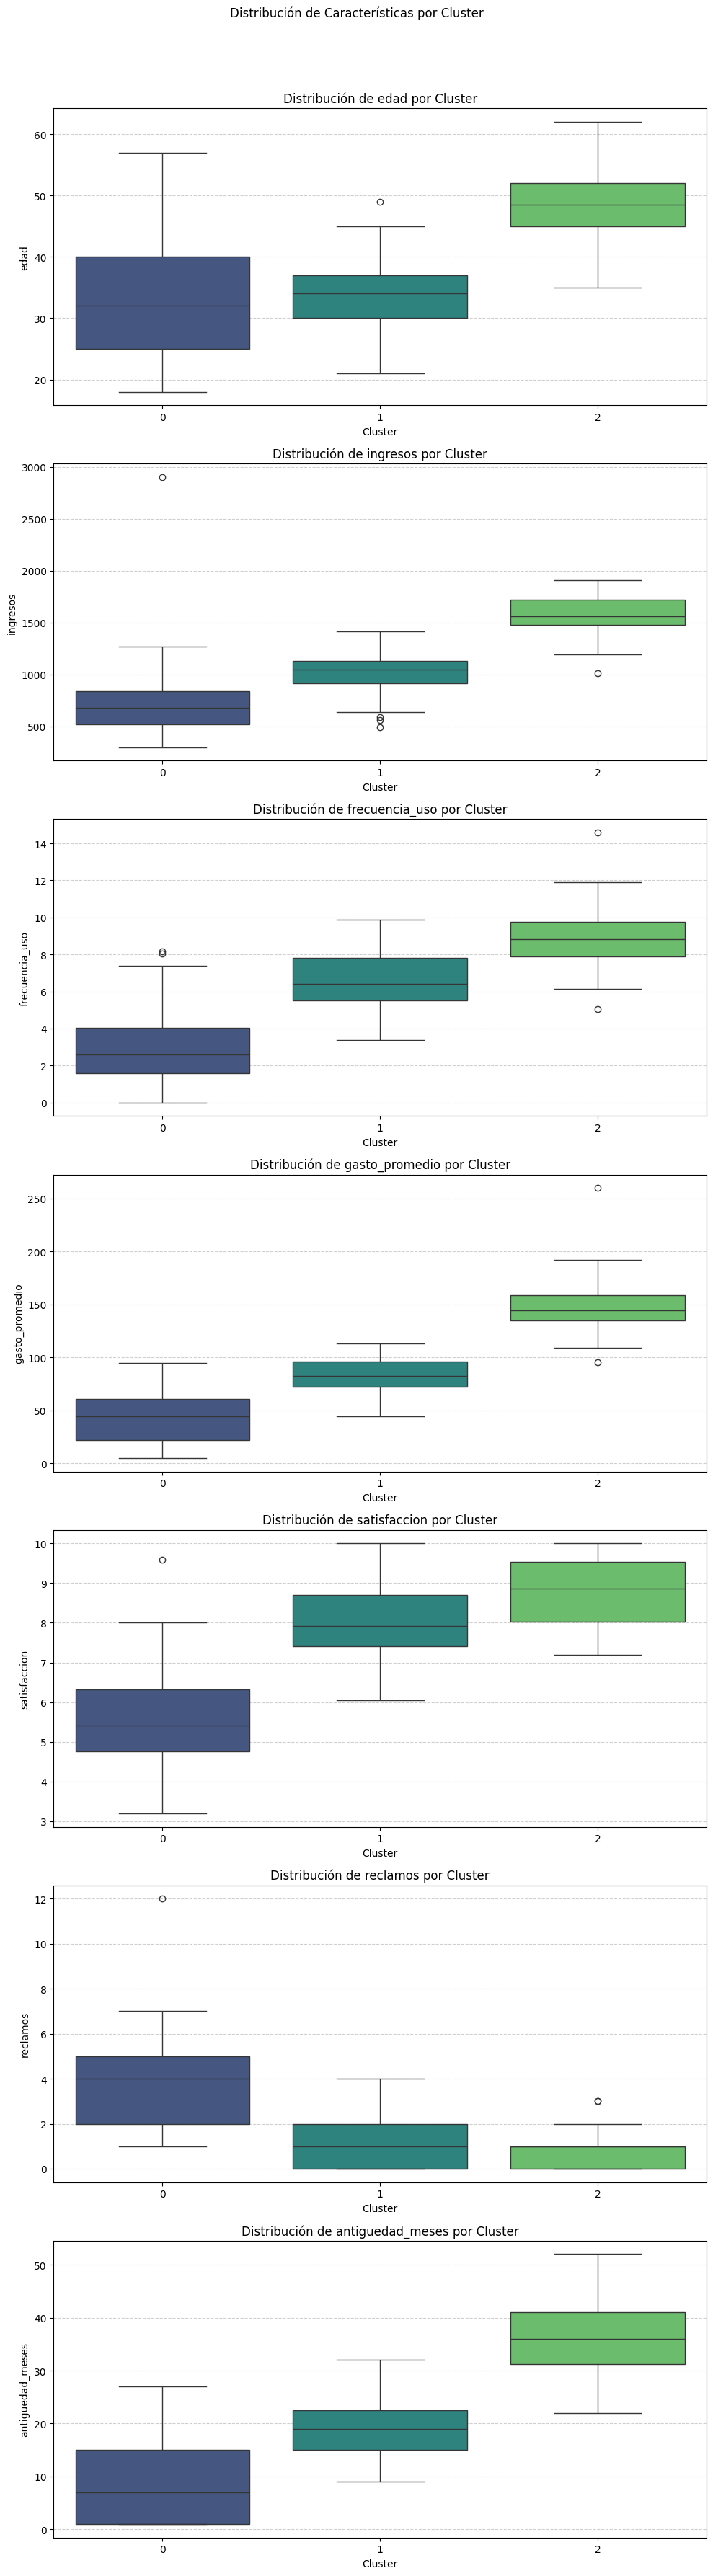

In [17]:
# Visualización de la distribución de cada característica por cluster (usando boxplots)

fig, axes = plt.subplots(nrows=len(clustering_features), ncols=1, figsize=(10, 5 * len(clustering_features)))
fig.suptitle('Distribución de Características por Cluster', y=1.02)

for i, feature in enumerate(clustering_features):
    sns.boxplot(ax=axes[i], x='cluster', y=feature, data=df, palette='viridis')
    axes[i].set_title(f'Distribución de {feature} por Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feature)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretación de los Clusters

Para interpretar cada cluster, debes analizar los valores promedio de las características (`edad`, `ingresos`, `frecuencia_uso`, `gasto_promedio`, `satisfaccion`, `reclamos`, `antiguedad_meses`) para cada grupo, como se muestra en la tabla generada anteriormente.

**Pasos para la Interpretación:**

1.  **Observa el tamaño de cada cluster:** La tabla `df['cluster'].value_counts()` te indica cuántos clientes hay en cada grupo. Esto te dará una idea de la proporción de cada segmento.
2.  **Compara los promedios de las características:** Examina la tabla `df.groupby('cluster')[clustering_features].mean()`. Busca las diferencias más significativas entre los clusters para cada característica.
    *   Por ejemplo, si el `Cluster 0` tiene `ingresos` y `gasto_promedio` mucho más altos que los otros clusters, podrías empezar a definirlo como un grupo de 'Clientes de Alto Valor'.
    *   Si el `Cluster 1` tiene una `frecuencia_uso` alta pero un `gasto_promedio` bajo, podría ser 'Clientes Frecuentes de Bajo Gasto'.
    *   Si el `Cluster 2` tiene una `satisfaccion` baja y muchos `reclamos`, podría ser 'Clientes Insatisfechos con Riesgo de Fuga'.
3.  **Asigna un nombre descriptivo:** Una vez que hayas identificado las características dominantes de cada grupo, asigna un nombre que resuma su perfil. Estos nombres harán que los clusters sean más fáciles de recordar y comunicar a otras personas.

**Ejemplo de Interpretación (basado en los resultados que obtuviste):**

*   **Cluster 0:** [Describe las características distintivas basadas en los promedios]
*   **Cluster 1:** [Describe las características distintivas basadas en los promedios]
*   **Cluster 2:** [Describe las características distintivas basadas en los promedios]

Este análisis te permitirá entender el comportamiento y las necesidades de cada segmento de clientes, lo cual es fundamental para estrategias de marketing personalizadas, desarrollo de productos o mejoras en el servicio al cliente.

### Proponer Acciones de Negocio para Cada Grupo

Una vez que hayas interpretado y, posiblemente, nombrado cada cluster, el objetivo final es diseñar estrategias de negocio diferenciadas que resuenen con las necesidades y comportamientos específicos de cada segmento.

**Guía para la Propuesta de Acciones:**

Para cada cluster que identificaste, considera las siguientes preguntas para generar acciones de negocio:

1.  **¿Cuáles son sus características principales?** (Basado en la interpretación de los promedios de las variables).
2.  **¿Qué necesidades o deseos no satisfechos podrían tener?**
3.  **¿Qué problemas o puntos de dolor experimentan?**
4.  **¿Cómo podemos mejorar su experiencia o aumentar su valor para la empresa?**
5.  **¿Qué canales de comunicación o marketing serían más efectivos para ellos?**

**Ejemplos de Acciones por Tipo de Cluster (adapta según tus resultados):**

*   **Para un 'Cluster de Clientes de Alto Valor':**
    *   **Marketing:** Programas de lealtad exclusivos, ofertas premium, comunicación personalizada (gerente de cuenta).
    *   **Producto/Servicio:** Acceso anticipado a nuevos productos, servicios VIP, atención al cliente prioritaria.
    *   **Retención:** Encuestas de satisfacción proactivas, invitaciones a eventos exclusivos.

*   **Para un 'Cluster de Clientes Frecuentes de Bajo Gasto':**
    *   **Marketing:** Promociones por volumen, incentivos para aumentar el ticket promedio, upselling/cross-selling de productos complementarios.
    *   **Producto/Servicio:** Kits de ahorro, paquetes de valor, recomendación de productos de mayor margen.
    *   **Retención:** Reconocimiento por lealtad, comunicación sobre nuevos usos de productos.

*   **Para un 'Cluster de Clientes Insatisfechos con Riesgo de Fuga':**
    *   **Marketing:** Campañas de recuperación con ofertas especiales, comunicaciones empáticas, recopilación de feedback para mejoras.
    *   **Producto/Servicio:** Resolución proactiva de problemas, mejoras en el servicio postventa, canales de soporte accesibles.
    *   **Retención:** Contacto personal para entender y resolver quejas, monitoreo de la satisfacción después de la intervención.

*   **Para un 'Cluster de Clientes Nuevos o Potenciales':**
    *   **Marketing:** Campañas de bienvenida, guías de inicio, promociones de primera compra.
    *   **Producto/Servicio:** Demostraciones de productos, tutoriales, soporte de onboarding.
    *   **Retención:** Seguimiento post-compra, recopilación de feedback temprano.

Al aplicar esta metodología, podrás transformar tus clusters en segmentos accionables, lo que te permitirá tomar decisiones estratégicas más informadas y efectivas.\